In [2]:
#  Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report, roc_curve, auc
)
import joblib

In [3]:
#  Step 2: Load Dataset
df_clean = pd.read_csv("processed_dataset.csv")
print("Dataset shape:", df_clean.shape)
print(df_clean.head())

Dataset shape: (62242, 11)
     weight     ap_hi     ap_lo  age_years       bmi  high_bp  cholesterol_2  \
0 -0.914410 -1.148225 -0.219747  -0.431332 -1.132933        0              0   
1  0.985443  0.953411  1.084599   0.310395  1.737418        1              0   
2 -0.749206  0.252866 -1.524093  -0.282986 -0.791720        0              0   
3  0.737636  1.653956  2.388945  -0.728022  0.360506        1              0   
4 -0.501399 -0.447679 -0.219747   1.052121  0.509819        0              1   

   cholesterol_3  gluc_2  gluc_3  cardio  
0              0       0       0       0  
1              1       0       0       1  
2              1       0       0       1  
3              0       0       0       1  
4              0       1       0       0  


In [4]:
#  Step 3: Split Features and Target
X = df_clean.drop('cardio', axis=1)
y = df_clean['cardio']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [5]:
# Step 4: Train Random Forest Model
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    random_state=42
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
# Step 5: Predictions
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]  # probabilities for ROC curve

 Model Accuracy: 0.69

 Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.69      0.70      6312
           1       0.69      0.69      0.69      6137

    accuracy                           0.69     12449
   macro avg       0.69      0.69      0.69     12449
weighted avg       0.69      0.69      0.69     12449



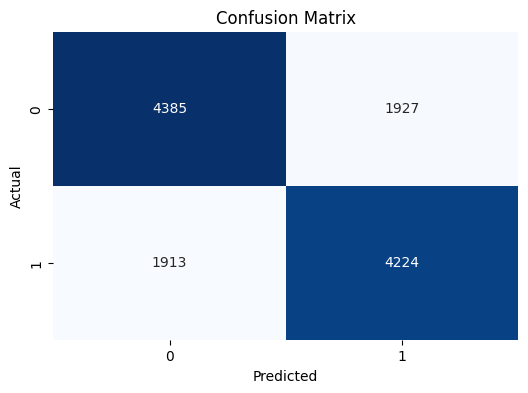

In [7]:
#  Step 6: Model Evaluation
accuracy = accuracy_score(y_test, y_pred)
print(f" Model Accuracy: {accuracy:.2f}")

print("\n Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

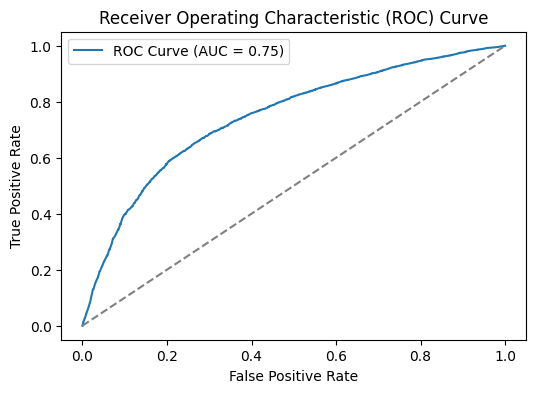

In [8]:
# 📈 Step 7: ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()

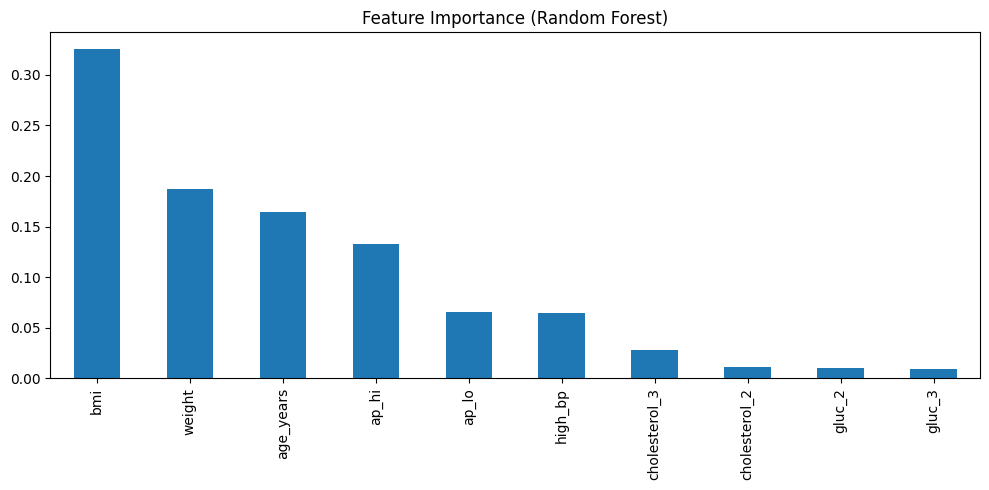

In [9]:
# Step 8: Feature Importance
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(10,5))
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.show()

In [10]:
# Step 9: Save the Model
joblib.dump(rf_model, "random_forest_model.pkl")
print(" Model saved as random_forest_model.pkl")

 Model saved as random_forest_model.pkl


In [1]:
# Step 10: Hyperparameter Tuning (GridSearchCV)   

 Running Grid Search... (this may take several minutes)
Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Hyperparameters Found:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}

 Tuned Model Accuracy: 0.73

 Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      6312
           1       0.76      0.67      0.71      6137

    accuracy                           0.73     12449
   macro avg       0.73      0.73      0.73     12449
weighted avg       0.73      0.73      0.73     12449



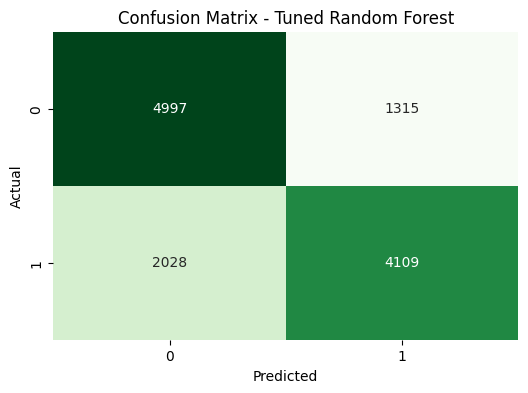

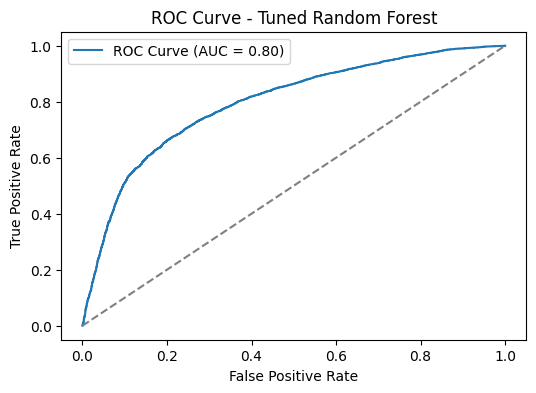

 Tuned model saved as random_forest_best_model.pkl


In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 300],        # number of trees
    'max_depth': [None, 10, 20, 30],        # tree depth
    'min_samples_split': [2, 5, 10],        # min samples to split a node
    'min_samples_leaf': [1, 2, 4],          # min samples per leaf
    'criterion': ['gini', 'entropy']        # splitting method
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,                # 5-fold cross-validation
    n_jobs=-1,           # use all CPU cores
    verbose=2
)

# Fit the model
print(" Running Grid Search... (this may take several minutes)")
grid_search.fit(X_train, y_train)

# Display best parameters
print("\nBest Hyperparameters Found:")
print(grid_search.best_params_)

# Get the best model
best_rf_model = grid_search.best_estimator_

# Evaluate tuned model
y_pred_best = best_rf_model.predict(X_test)
y_proba_best = best_rf_model.predict_proba(X_test)[:, 1]

# Accuracy
best_accuracy = accuracy_score(y_test, y_pred_best)
print(f"\n Tuned Model Accuracy: {best_accuracy:.2f}")

print("\n Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_best))

# Confusion Matrix for tuned model
cm_best = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6,4))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - Tuned Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve for tuned model
fpr_best, tpr_best, thresholds_best = roc_curve(y_test, y_proba_best)
roc_auc_best = auc(fpr_best, tpr_best)

plt.figure(figsize=(6,4))
plt.plot(fpr_best, tpr_best, label=f"ROC Curve (AUC = {roc_auc_best:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.legend()
plt.show()

# Save tuned model
joblib.dump(best_rf_model, "random_forest_best_model.pkl")
print(" Tuned model saved as random_forest_best_model.pkl")



📊 Model Performance Comparison:
            Model  Accuracy  AUC Score
0   Base RF Model  0.691541   0.745821
1  Tuned RF Model  0.731464   0.795746


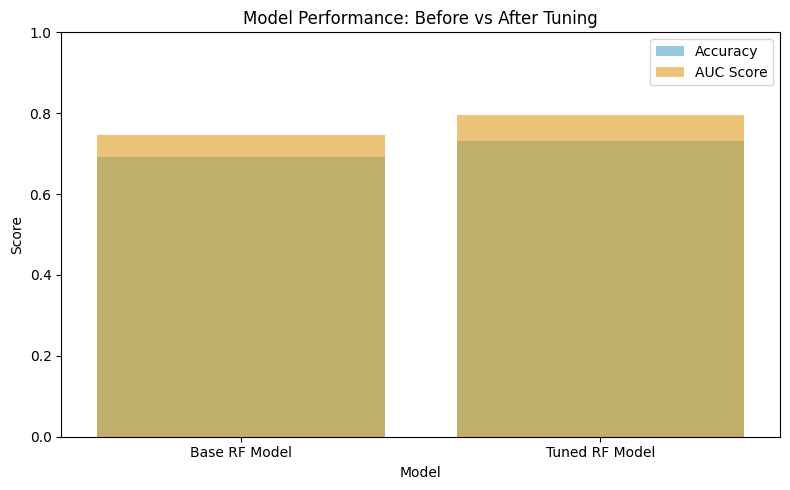

In [14]:
# 📈 Step 11: Compare Performance

# Collect metrics
metrics = {
    "Model": ["Base RF Model", "Tuned RF Model"],
    "Accuracy": [accuracy, best_accuracy],
    "AUC Score": [roc_auc, roc_auc_best]
}

comparison_df = pd.DataFrame(metrics)

# Display the comparison table
print("\n📊 Model Performance Comparison:")
print(comparison_df)

# Plot comparison
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=comparison_df, color="skyblue", label="Accuracy")
sns.barplot(x="Model", y="AUC Score", data=comparison_df, color="orange", alpha=0.6, label="AUC Score")

plt.title("Model Performance: Before vs After Tuning")
plt.ylim(0, 1)
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


In [16]:
import os

print("Current Working Directory:", os.getcwd())


Current Working Directory: C:\Users\donac\OneDrive\Desktop\AIML\project


In [17]:
#Checking the model 

In [18]:
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


0.691541489276247
[[4385 1927]
 [1913 4224]]
              precision    recall  f1-score   support

           0       0.70      0.69      0.70      6312
           1       0.69      0.69      0.69      6137

    accuracy                           0.69     12449
   macro avg       0.69      0.69      0.69     12449
weighted avg       0.69      0.69      0.69     12449



In [11]:
#check if the saved .pkl file loads correctly and predicts new data.

#Load the Saved Mode
import joblib

# Load the tuned model
model = joblib.load("random_forest_best_model.pkl")
print(" Model loaded successfully!")


 Model loaded successfully!


In [12]:
#Predict on Test Data

# Use the same test set as before
y_pred_loaded = model.predict(X_test)

# Check if results match earlier model
from sklearn.metrics import accuracy_score

print("Loaded Model Accuracy:", accuracy_score(y_test, y_pred_loaded))


Loaded Model Accuracy: 0.7314643746485662


In [13]:
#Test with a New Sample

new_patient = pd.DataFrame({
    'weight': [72],          # kg
    'ap_hi': [130],          # systolic BP
    'ap_lo': [85],           # diastolic BP
    'age_years': [55],       # age
    'bmi': [26.4],           # body mass index
    'high_bp': [1],          # 1 = high BP, 0 = normal
    'cholesterol_2': [1],    # 1 = above normal cholesterol
    'cholesterol_3': [0],    # 1 = well above normal cholesterol
    'gluc_2': [0],           # 1 = above normal glucose
    'gluc_3': [0]            # 1 = well above normal glucose
})

#  Predict
pred = model.predict(new_patient)
prob = model.predict_proba(new_patient)[0][1]

print("\n Model Prediction Result:")
if pred[0] == 1:
    print(f" The model predicts: Cardiovascular Disease (Probability: {prob:.2f})")
else:
    print(f" The model predicts: No Cardiovascular Disease (Probability: {prob:.2f})")



 Model Prediction Result:
 The model predicts: Cardiovascular Disease (Probability: 0.83)


In [14]:
#test multiple patients at once
new_patients = pd.DataFrame([
    [72, 130, 85, 55, 26.4, 1, 1, 0, 0, 0],
    [80, 145, 90, 63, 28.7, 1, 0, 1, 1, 0]
], columns=['weight','ap_hi','ap_lo','age_years','bmi','high_bp','cholesterol_2','cholesterol_3','gluc_2','gluc_3'])

predictions = model.predict(new_patients)
print(predictions)

[1 1]
